In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/marketing_campaign-selected-columns.csv')

####Content
- **ID:** Customer's unique identifier
- **Year_Birth:** Customer's birth year
- **Education:** Customer's education level
- **Marital_Status:** Customer's marital status
- **Income:** Customer's yearly household income
- **Kidhome:**  Number of children in customer's household
- **Teenhome:** Number of teenagers in customer's household
- **Dt_Customer:** Date of customer's enrollment with the company
- **Recency:** Number of days since customer's last purchase
- **Complain:** 1 if the customer complained in the last 2 years, 0 otherwise

In [ ]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              2240 non-null   int64  
 1   Year_Birth      2240 non-null   int64  
 2   Education       2240 non-null   object 
 3   Marital_Status  2240 non-null   object 
 4   Income          2216 non-null   float64
 5   Kidhome         2240 non-null   int64  
 6   Teenhome        2240 non-null   int64  
 7   Dt_Customer     2240 non-null   object 
 8   Recency         2240 non-null   int64  
 9   MntWines        2240 non-null   int64  
dtypes: float64(1), int64(6), object(3)
memory usage: 175.1+ KB


In [ ]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000


####Data Cleaning
- missing values in Income Column
- converting Dt_Customer into DateTime data type
- combine Kidhome & Teenhome as single column 'family size'
- create new column to check if customer have children or not if yes then 1 else 0



In [ ]:
df[df['Income'].isnull()]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines
10,1994,1983,Graduation,Married,NaN,1,0,15-11-2013,11,5
27,5255,1986,Graduation,Single,NaN,1,0,20-02-2013,19,5
43,7281,1959,PhD,Single,NaN,0,0,05-11-2013,80,81
48,7244,1951,Graduation,Single,NaN,2,1,01-01-2014,96,48
58,8557,1982,Graduation,Single,NaN,1,0,17-06-2013,57,11
71,10629,1973,2n Cycle,Married,NaN,1,0,14-09-2012,25,25
90,8996,1957,PhD,Married,NaN,2,1,19-11-2012,4,230
91,9235,1957,Graduation,Single,NaN,1,1,27-05-2014,45,7
92,5798,1973,Master,Together,NaN,0,0,23-11-2013,87,445
128,8268,1961,PhD,Married,NaN,0,1,11-07-2013,23,352


<Axes: >

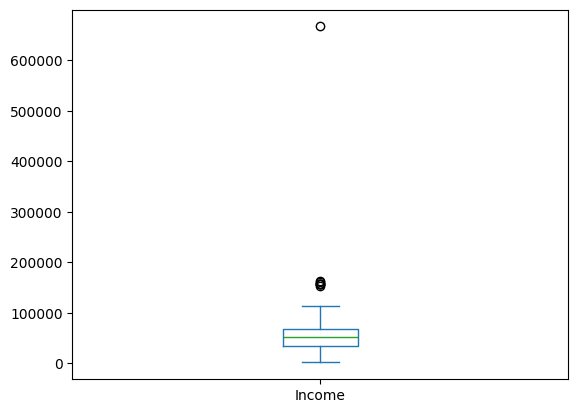

In [ ]:
df['Income'].plot(kind='box')

In [ ]:
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3 - Q1

# Define upper boundary
upper_bound = Q3 + 1.5 * IQR

# Option A: Filter out rows beyond upper bound
df = df[df['Income'] <= upper_bound]

# Option B: Capping (Winsorization) - set outliers to the upper boundary value instead of dropping
df['Income'] = df['Income'].clip(upper=upper_bound)

In [ ]:
df['Income']

,Income
0,58138.0
1,46344.0
2,71613.0
3,26646.0
4,58293.0
...,...
2235,61223.0
2236,64014.0
2237,56981.0
2238,69245.0


In [ ]:
df['Income']=df['Income'].fillna(df['Income'].mean())

In [ ]:
df['Income'].isnull().sum()

np.int64(0)

<Axes: >

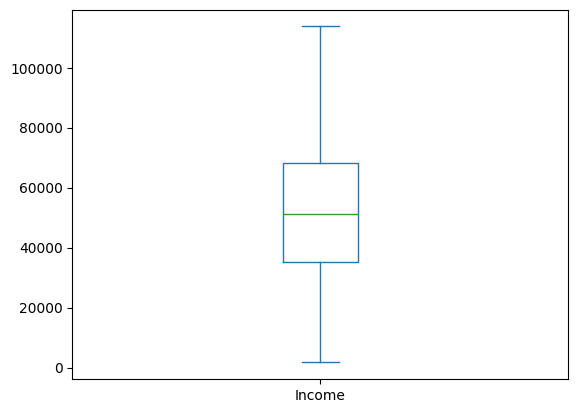

In [ ]:

df['Income'].plot(kind='box')

In [ ]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173
...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428


In [ ]:
df['Dt_Customer']=pd.to_datetime(df['Dt_Customer'],format='%d-%m-%Y')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2208 entries, 0 to 2239
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ID              2208 non-null   int64         
 1   Year_Birth      2208 non-null   int64         
 2   Education       2208 non-null   object        
 3   Marital_Status  2208 non-null   object        
 4   Income          2208 non-null   float64       
 5   Kidhome         2208 non-null   int64         
 6   Teenhome        2208 non-null   int64         
 7   Dt_Customer     2208 non-null   datetime64[ns]
 8   Recency         2208 non-null   int64         
 9   MntWines        2208 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(6), object(2)
memory usage: 189.8+ KB


In [ ]:
df[df.duplicated(subset=['ID'])]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines


In [ ]:
df['Marital_Status'].value_counts()

,count
Marital_Status,
Married,854
Together,569
Single,471
Divorced,231
Widow,76
Alone,3
Absurd,2
YOLO,2


In [ ]:
marital_map={
    'Married':2,
    'Together':2,
    'Single':1,
    'Divorced':1,
    'Widow':1,
    'Alone':1,
    'Absurd':1,
    'YOLO':1

}
df['Family_size']=df['Marital_Status'].map(marital_map) + df['Kidhome']+df['Teenhome']

In [ ]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,Family_size
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,3
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,2
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,3
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,3
...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,3
2236,4001,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,5
2237,7270,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,1
2238,8235,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,3


In [ ]:
df['Has_children']=(df['Family_size']>1).astype(int)

In [ ]:
df.sample(5)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,Family_size,Has_children
1070,10536,1971,PhD,Together,32892.0,1,0,2014-05-25,78,26,3,1
1304,6055,1979,Graduation,Married,71626.0,0,0,2012-11-01,94,546,2,1
891,7108,1965,Master,Widow,51390.0,1,1,2012-09-08,54,205,3,1
1459,2525,1974,PhD,Married,38410.0,0,0,2012-09-14,65,153,2,1
1882,5180,1968,PhD,Divorced,50616.0,0,1,2014-04-18,56,128,2,1


In [ ]:
df.drop(columns=['Kidhome','Teenhome'],inplace=True)

In [ ]:
df.sample(5)

,ID,Year_Birth,Education,Marital_Status,Income,Dt_Customer,Recency,MntWines,Family_size,Has_children
270,2379,1953,Graduation,Single,69267.0,2012-09-22,31,778,1,0
24,1409,1951,Graduation,Together,40689.0,2013-03-18,69,270,3,1
871,9353,1959,Graduation,Single,62450.0,2014-01-06,61,515,2,1
1924,7966,1959,Graduation,Single,80982.0,2013-01-08,48,505,3,1
230,6798,1966,Graduation,Single,37070.0,2013-03-20,30,231,3,1


 #### Descriptive statistics:
 - average purchase value
 - purchase frequency
 - customer lifetime value


In [ ]:
#How much the average customer spends on wine

Avg_purchase_value=df['MntWines'].mean()

In [ ]:
Avg_purchase_value


np.float64(306.1009963768116)

In [ ]:

#How long the average customer has been with the company
df['time_of_customers']=(df['Dt_Customer'].max()-df['Dt_Customer']).dt.days/365

In [ ]:
df['time_of_customers']


,time_of_customers
0,1.816438
1,0.309589
2,0.854795
3,0.380822
4,0.441096
...,...
2235,1.043836
2236,0.052055
2237,0.424658
2238,0.427397


In [ ]:
# Find the average tenure across all customers
avg_tenure=df['time_of_customers'].mean()
avg_tenure

np.float64(0.9685130037720867)

In [ ]:
print(f'average money spend on wine :{Avg_purchase_value:.2f}')
print(f'average customer tenure :{avg_tenure:.0f}')

average money spend on wine :306.10
average customer tenure :1


In [ ]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Dt_Customer,Recency,MntWines,Family_size,Has_children,time_of_customers
0,5524,1957,Graduation,Single,58138.0,2012-09-04,58,635,1,0,1.816438
1,2174,1954,Graduation,Single,46344.0,2014-03-08,38,11,3,1,0.309589
2,4141,1965,Graduation,Together,71613.0,2013-08-21,26,426,2,1,0.854795
3,6182,1984,Graduation,Together,26646.0,2014-02-10,26,11,3,1,0.380822
4,5324,1981,PhD,Married,58293.0,2014-01-19,94,173,3,1,0.441096


In [ ]:
# Creating 3 features for clustering
features=['Income','Recency','MntWines']
x=df[features].copy()


In [ ]:
x.isnull().sum()

,0
Income,0
Recency,0
MntWines,0


In [ ]:
x.corr()

,Income,Recency,MntWines
Income,1.000000,0.005657,0.730488
Recency,0.005657,1.000000,0.015857
MntWines,0.730488,0.015857,1.000000


#### Observations
**Income & Wine Spend ($r = 0.73$)**: Correlation betwwn income and wine spend is high ,It means Customers with higher income levels spend significantly more on wine.Income is a major driving factor for customer spend capacity in this product category.

**No Linear Relationship:** Recency shows almost zero correlation with both Income ($0.0057$) and MntWines ($0.0159$).

### Why Use StandardScaler?
* **Prevents Feature Dominance:** K-Means relies on Euclidean distance; without scaling, features with large values (`Income` and `MntWines`) would completely dominate features with smaller values (`Recency`).
* **Equal Weighting:** `StandardScaler` transforms all features to have a **mean of 0** and a **standard deviation of 1**, ensuring each feature contributes equally to distance calculations.
* **Optimal Cluster Formation:** Standardisation prevents distorted, stretched clusters and helps K-Means discover natural, balanced customer segments.

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

X_scaled=scaler.fit_transform(x)

X_scaled=pd.DataFrame(X_scaled,columns=x.columns)
print("--- Scaled Feature Means (Target: 0) ---")
print(X_scaled.mean().round(4))

print("\n--- Scaled Feature Std Devs (Target: 1) ---")
print(X_scaled.std().round(4))

X_scaled.head()

--- Scaled Feature Means (Target: 0) ---
Income      0.0
Recency     0.0
MntWines   -0.0
dtype: float64

--- Scaled Feature Std Devs (Target: 1) ---
Income      1.0002
Recency     1.0002
MntWines    1.0002
dtype: float64


,Income,Recency,MntWines
0,0.314089,0.310588,0.974689
1,-0.255431,-0.380686,-0.874529
2,0.964782,-0.795450,0.355320
3,-1.206626,-0.795450,-0.874529
4,0.321573,1.554881,-0.394444


 Apply K-Means clustering — use the Elbow Method to determine optimal number of clusters ($K$)

In [ ]:
from sklearn.cluster import KMeans
wcss=[]
for i in range(1,11):
  kmeans=KMeans(n_clusters=i,random_state=42,n_init='auto')
  kmeans.fit(X_scaled)
  wcss.append(kmeans.inertia_)

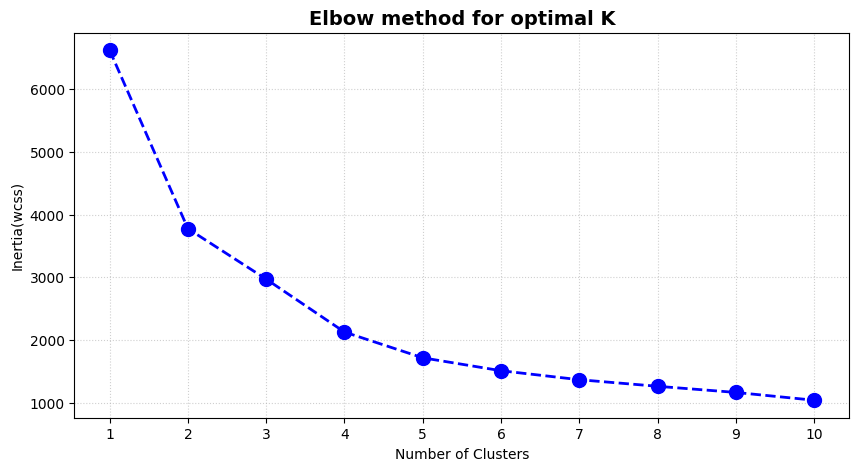

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(range(1,11),wcss,marker='o',color='b',markersize=10,linestyle='--',linewidth=2)
plt.title("Elbow method for optimal K",fontsize=14,fontweight='bold')
plt.xlabel("Number of Clusters")
plt.ylabel('Inertia(wcss)')
plt.xticks(range(1,11))
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

**Big Initial Drop ($K=1$ to $K=3$):** Error drops sharply up to 3 clusters, meaning data points get grouped much better.

**Clear Elbow at $K=3$:** A distinct bend ("elbow") forms right at 3 clusters.Slower Improvement After $K=3$: Adding 4 or more clusters gives very little extra benefit.

**Conclusion:** $K = 3$ is the sweet spot for creating simple, meaningful customer segments.

In [ ]:
optimal_k=3

kmeans=KMeans(n_clusters=optimal_k,random_state=42,n_init='auto')

df['Clusters']=kmeans.fit_predict(X_scaled)

In [ ]:
df['Clusters'].value_counts().sort_index()

,count
Clusters,
0,1117
1,519
2,572


In [ ]:
profile=df.groupby('Clusters')[['Income','Recency','MntWines']].mean().round()
profile

,Income,Recency,MntWines
Clusters,,,
0,34763.0,50.0,55.0
1,68568.0,21.0,530.0
2,69213.0,73.0,594.0


In [ ]:
profile['Customer_count']=df['Clusters'].value_counts().sort_index()
display(profile)

,Income,Recency,MntWines,Customer_count
Clusters,,,,
0,34763.0,50.0,55.0,1117
1,68568.0,21.0,530.0,519
2,69213.0,73.0,594.0,572


/tmp/ipykernel_604/2716363290.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index,y=counts.values,ax=axes[2],palette='Set1')


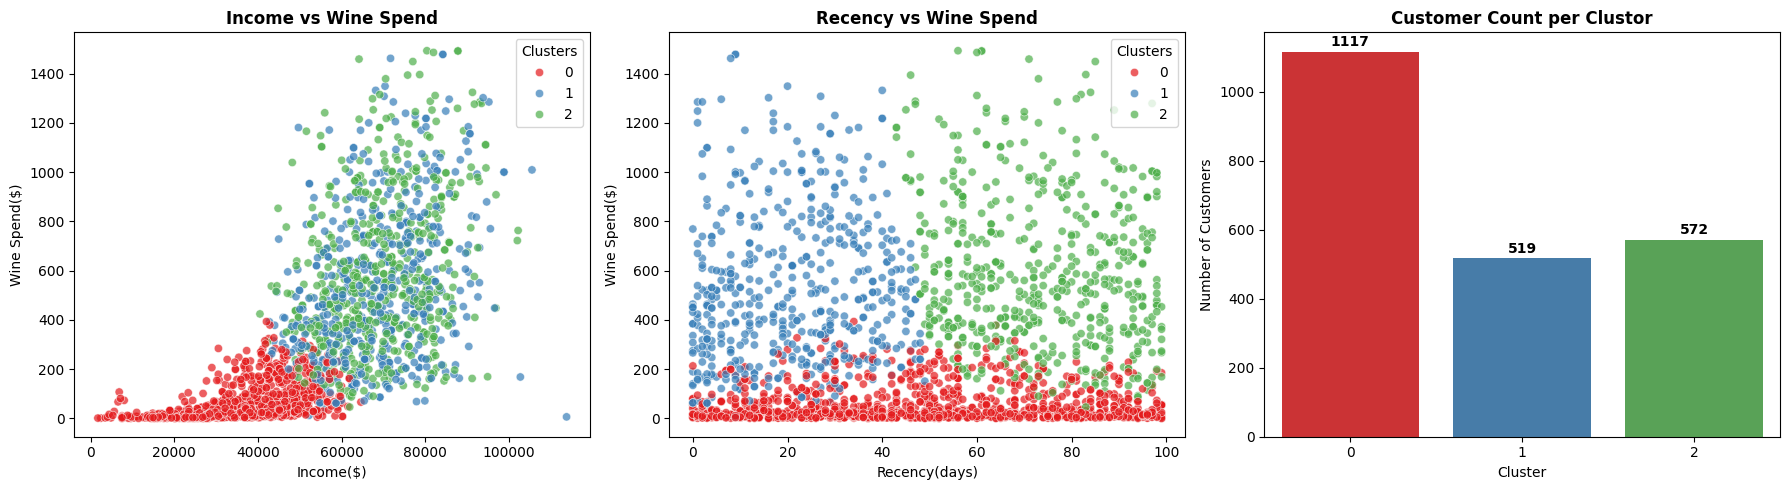

In [ ]:
import seaborn as sns

fig,axes=plt.subplots(1,3, figsize=(18,5))

sns.scatterplot(data=df,x='Income',y='MntWines',hue='Clusters',palette='Set1',ax=axes[0],alpha=0.7)
axes[0].set_title('Income vs Wine Spend',fontsize=12,fontweight='bold')
axes[0].set_xlabel('Income($)')
axes[0].set_ylabel('Wine Spend($)')

sns.scatterplot(data=df,x='Recency',y='MntWines',hue='Clusters',palette='Set1',ax=axes[1],alpha=0.7)
axes[1].set_title('Recency vs Wine Spend',fontsize=12,fontweight='bold')
axes[1].set_xlabel('Recency(days)')
axes[1].set_ylabel('Wine Spend($)')

counts=df['Clusters'].value_counts().sort_index()
sns.barplot(x=counts.index,y=counts.values,ax=axes[2],palette='Set1')
axes[2].set_title('Customer Count per Clustor',fontsize=12,fontweight='bold')
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('Number of Customers')

for i,count in enumerate(counts.values):
  axes[2].text(i,count+15,str(count),ha='center',fontweight='bold')
plt.tight_layout()
plt.show()


#### Observations

1. **Scatter Plot 1:** Income vs. Wine Spend Observations
Income Drives Spending Capacity: Customers with higher annual income ($50,000–$100,000+) spend significantly more on wine ($200–$1,500+).

Budget Clustering: Lower-income customers ($0–$50,000) stay tightly clustered at lower spending levels ($0–$300).

Overlap: Income alone separates high spenders from low spenders, but cannot separate active spenders from lapsed spenders.

2. **Scatter Plot 2:** Recency vs. Wine Spend Observations
Behavioral Separation: Recency (days since last purchase) successfully splits high-value customers into two clear operational groups:

Active Spenders: High spenders who bought recently (0–50 days ago).

At-Risk Spenders: High spenders who have not purchased in a long time (50–100 days ago).

Universal Recency Spread: Recency is evenly spread across all spending levels, making it an independent and effective dimension for customer engagement tracking.

3. **Bar Chart:** Customer Distribution Observations
Mass Market Majority: Cluster 0 (Budget Shoppers) represents about 50% of the entire customer base, showing that half of the user base consists of price-sensitive buyers.

Balanced VIP Base: The remaining 50% of customers are split almost evenly between:

Active VIPs (~23–25%): Currently generating regular high revenue.

At-Risk VIPs (~25–27%): Past high spenders requiring urgent re-engagement.

#### Simple Marketing Action Plan

1. **Cluster 1:** The High Spenders (Active VIPs)
Who they are: 519 loyal customers who spend a lot of money and buy often.

- Why they matter: They bring in the biggest chunk of your profit.

- What to do:

    Treat them like royalty: Give them special perks like free shipping, early access to new items, or invites to VIP events.

     Focus on appreciation: Don't waste money on small discount codes—make them feel valued so they stay with you long-term.



2. **Cluster 2:**  The Missing Big Spenders (At-Risk VIPs)
Who they are: 572 rich customers who used to spend heavily, but haven't bought anything in 2 to 3 months.

- Why they matter: Losing them will hurt your revenue badly.

- What to do:

   Win them back quickly:  with a special discount coupon (like $20 off) to bring them back.

   Remind them what they love: Show them personalized product recommendations based on their past purchases.

3. **Cluster 0:** The Bargain Hunters (Budget Shoppers)
Who they are: 1,117 price-sensitive customers (half of your total buyers) who spend smaller amounts.

- Why they matter: Even though individual spending is low, there are so many of them that their combined purchases add up to big money.

- What to do:

    Sell in bulk: Use deal packages (like "Buy 2 bottles, get 10% off") to encourage them to spend just a little more each visit.

    Promote value: Run seasonal sales and highlight budget-friendly options.